# Retrieval Quality — Recall@k
R@k as a function of `poison_rate` and `k` (top-K retrieved) over 100 FEVER examples. Embedding only, no LLM calls.

In [8]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

with open("../configs/config.yaml") as f:
    cfg = yaml.safe_load(f)

SEED = cfg["seed"]
DISTRACTOR_POOL = cfg["retrieval"]["distractor_pool_size"]
EMBEDDING_MODEL = cfg["retrieval"]["embedding_model"]
CACHE_DIR = os.path.join("..", cfg["cache"]["dir"], cfg["cache"]["embeddings_subdir"])

K_VALUES = [3, 5, 10]
POISON_RATES = [0.0, 0.25, 0.5, 0.75, 1.0]
N_EXAMPLES = 100

print(f"seed={SEED}  distractor_pool={DISTRACTOR_POOL}")
print(f"k sweep: {K_VALUES}")
print(f"poison_rate sweep: {POISON_RATES}")
print(f"n_examples: {N_EXAMPLES}")

seed=42  distractor_pool=20
k sweep: [3, 5, 10]
poison_rate sweep: [0.0, 0.25, 0.5, 0.75, 1.0]
n_examples: 100


In [9]:
from src.data.fever_loader import load_fever
from src.data.poisoner import poison_dataset
from src.retrieval.corpus import build_all_corpora
from src.retrieval.embedder import Embedder
from src.retrieval.retriever import Retriever
from src.evaluation.metrics import recall_at_k

all_examples = load_fever("../" + cfg["dataset"]["fever_dev"])

# Keep only examples with at least one evidence passage (needed for P@k to be meaningful)
examples_with_ev = [e for e in all_examples if e["evidence"]]
examples = examples_with_ev[:N_EXAMPLES]

print(f"Total examples loaded : {len(all_examples):,}")
print(f"With evidence         : {len(examples_with_ev):,}")
print(f"Using for sweep       : {len(examples):,}")

Total examples loaded : 15,935
With evidence         : 15,873
Using for sweep       : 100


In [ ]:
# Single embedder instance shared across all conditions to maximise cache hits
embedder = Embedder(
    model_name=EMBEDDING_MODEL,
    cache_dir=CACHE_DIR,
)
print(f"Embedder ready - dim={embedder.embedding_dim}")

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Embedder ready — dim=1024


In [11]:
def run_precision_sweep(examples, embedder, k_values, poison_rates,
                        distractor_pool=20, seed=42):
    """Returns DataFrame [poison_rate, k, mean_recall_at_k, n]."""
    rows = []

    for poison_rate in poison_rates:
        if poison_rate > 0.0:
            poisoned = poison_dataset(examples, poison_rate=poison_rate, seed=seed)
        else:
            poisoned = examples

        corpora = build_all_corpora(poisoned, distractor_pool_size=distractor_pool, seed=seed)

        for k in k_values:
            retriever = Retriever(embedder, k=k)
            precisions = []

            for ex, corpus in zip(poisoned, corpora):
                retriever.build(corpus)
                retrieved = retriever.retrieve(ex["claim"], k=k)
                gold = [corpus.passages[i] for i in corpus.gold_indices]
                precisions.append(recall_at_k(retrieved, gold) if gold else 0.0)

            mean_p = float(np.mean(precisions)) if precisions else 0.0
            rows.append({"poison_rate": poison_rate, "k": k,
                         "mean_recall_at_k": mean_p, "n": len(precisions)})
            print(f"  poison_rate={poison_rate:.2f}  k={k:2d}  R@k={mean_p:.4f}  "
                  f"(n={len(precisions)})")

    return pd.DataFrame(rows)


print("Starting sweep (embeddings cached after first run)...")
results = run_precision_sweep(
    examples, embedder,
    k_values=K_VALUES,
    poison_rates=POISON_RATES,
    distractor_pool=DISTRACTOR_POOL,
    seed=SEED,
)
print("\nSweep done.")

Starting sweep (embeddings cached after first run)...
  poison_rate=0.00  k= 3  R@k=0.9288  (n=100)
  poison_rate=0.00  k= 5  R@k=0.9470  (n=100)
  poison_rate=0.00  k=10  R@k=0.9683  (n=100)
  poison_rate=0.25  k= 3  R@k=0.6960  (n=100)
  poison_rate=0.25  k= 5  R@k=0.7160  (n=100)
  poison_rate=0.25  k=10  R@k=0.7480  (n=100)
  poison_rate=0.50  k= 3  R@k=0.5622  (n=100)
  poison_rate=0.50  k= 5  R@k=0.5722  (n=100)
  poison_rate=0.50  k=10  R@k=0.5844  (n=100)
  poison_rate=0.75  k= 3  R@k=0.2650  (n=100)
  poison_rate=0.75  k= 5  R@k=0.2650  (n=100)
  poison_rate=0.75  k=10  R@k=0.2700  (n=100)
  poison_rate=1.00  k= 3  R@k=0.0000  (n=100)
  poison_rate=1.00  k= 5  R@k=0.0000  (n=100)
  poison_rate=1.00  k=10  R@k=0.0000  (n=100)

Sweep done.


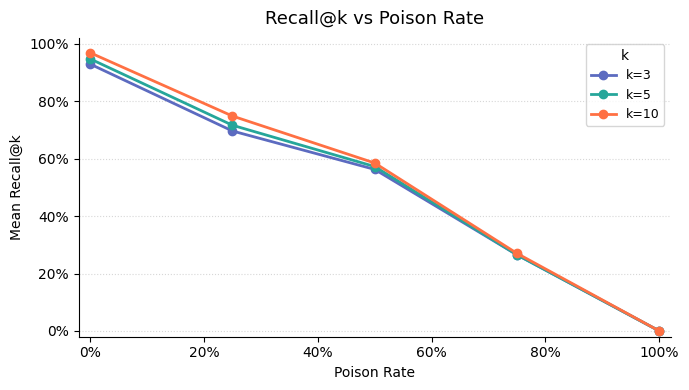

Saved → figures/02_recall_at_k_vs_poison_rate.png


In [ ]:
# --- Recall@k vs poison_rate - one line per k ---
K_COLORS = {3: "#5C6BC0", 5: "#26A69A", 10: "#FF7043"}

fig, ax = plt.subplots(figsize=(7, 4))

for k in K_VALUES:
    sub = results[results["k"] == k].sort_values("poison_rate")
    ax.plot(
        sub["poison_rate"], sub["mean_recall_at_k"],
        marker="o", linewidth=2, markersize=6,
        color=K_COLORS[k], label=f"k={k}",
    )

ax.set_title("Recall@k vs Poison Rate", fontsize=13, pad=10)
ax.set_xlabel("Poison Rate")
ax.set_ylabel("Mean Recall@k")
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend(title="k", fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", linestyle=":", alpha=0.5)

plt.tight_layout()
plt.savefig("../figures/02_recall_at_k_vs_poison_rate.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → figures/02_recall_at_k_vs_poison_rate.png")

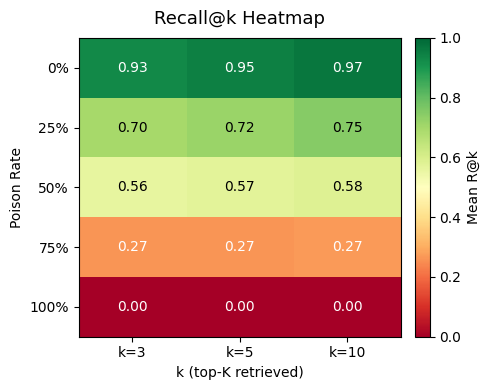

Saved → figures/02_precision_heatmap.png


In [13]:
# --- Heatmap: poison_rate × k ---
pivot = results.pivot(index="poison_rate", columns="k", values="mean_recall_at_k")

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(pivot.values, aspect="auto", cmap="RdYlGn", vmin=0, vmax=1)

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([f"k={k}" for k in pivot.columns])
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels([f"{r:.0%}" for r in pivot.index])
ax.set_xlabel("k (top-K retrieved)")
ax.set_ylabel("Poison Rate")
ax.set_title("Recall@k Heatmap", fontsize=13, pad=10)

for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        val = pivot.values[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                fontsize=10, color="black" if 0.3 < val < 0.85 else "white")

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Mean R@k")
plt.tight_layout()
plt.savefig("../figures/02_precision_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → figures/02_precision_heatmap.png")

In [14]:
# --- Summary table ---
table = results.copy()
table["poison_rate"] = table["poison_rate"].map("{:.0%}".format)
table["mean_recall_at_k"] = table["mean_recall_at_k"].map("{:.4f}".format)
table = table.set_index(["poison_rate", "k"])
print(table.to_string())


               mean_recall_at_k    n
poison_rate k                       
0%          3            0.9288  100
            5            0.9470  100
            10           0.9683  100
25%         3            0.6960  100
            5            0.7160  100
            10           0.7480  100
50%         3            0.5622  100
            5            0.5722  100
            10           0.5844  100
75%         3            0.2650  100
            5            0.2650  100
            10           0.2700  100
100%        3            0.0000  100
            5            0.0000  100
            10           0.0000  100


## Distractor Pool Size Ablation
Recall@k (k=5, poison_rate=0) as a function of `distractor_pool_size` D ∈ {5, 10, 20, 50}.
Justifies the choice D=20: small D makes retrieval trivially easy; D=20 provides a meaningful challenge.

In [ ]:
D_VALUES = [5, 10, 20, 50]
K_ABLATION = 5

def run_distractor_ablation(examples, embedder, d_values, k=5, seed=42):
    """Recall@k at poison_rate=0 for each distractor pool size."""
    import numpy as np
    rows = []
    for d in d_values:
        corpora = build_all_corpora(examples, distractor_pool_size=d, seed=seed)
        retriever = Retriever(embedder, k=k)
        recalls = []
        for ex, corpus in zip(examples, corpora):
            retriever.build(corpus)
            retrieved = retriever.retrieve(ex["claim"], k=k)
            gold = [corpus.passages[i] for i in corpus.gold_indices]
            pool_size = len(corpus.passages)
            recalls.append(recall_at_k(retrieved, gold) if gold else 0.0)
        mean_r = float(np.mean(recalls))
        mean_pool = float(np.mean([len(build_all_corpora([ex], distractor_pool_size=d)[0].passages)
                                   for ex in examples[:20]]))
        rows.append({"D": d, "mean_recall_at_k": mean_r, "approx_pool_size": mean_pool})
        print(f"  D={d:2d}  pool≈{mean_pool:.0f}  R@{k}={mean_r:.4f}")
    return pd.DataFrame(rows)

print(f"Distractor ablation - k={K_ABLATION}, poison_rate=0, n={len(examples)}")
df_ablation = run_distractor_ablation(examples, embedder, D_VALUES, k=K_ABLATION, seed=SEED)


Distractor ablation — k=5, poison_rate=0, n=100
  D= 5  pool≈1  R@5=0.9777
  D=10  pool≈1  R@5=0.9577
  D=20  pool≈1  R@5=0.9470
  D=50  pool≈1  R@5=0.9320


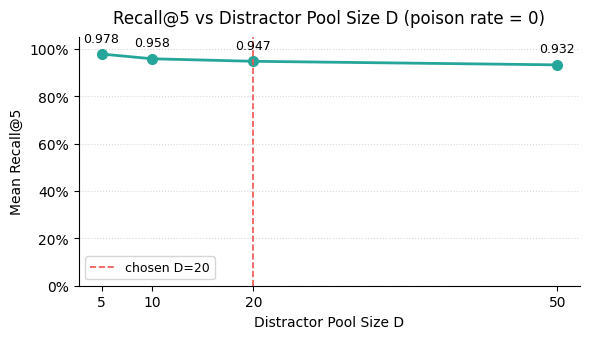

Saved → figures/02b_distractor_ablation.png


In [16]:
fig, ax = plt.subplots(figsize=(6, 3.5))

ax.plot(df_ablation["D"], df_ablation["mean_recall_at_k"],
        marker="o", linewidth=2, markersize=7, color="#26A69A")

for _, row in df_ablation.iterrows():
    ax.annotate(f"{row['mean_recall_at_k']:.3f}",
                xy=(row["D"], row["mean_recall_at_k"]),
                xytext=(0, 9), textcoords="offset points",
                ha="center", fontsize=9)

ax.axvline(x=20, color="#EF5350", linestyle="--", linewidth=1.2, label="chosen D=20")
ax.set_title(f"Recall@{K_ABLATION} vs Distractor Pool Size D (poison rate = 0)", fontsize=12, pad=10)
ax.set_xlabel("Distractor Pool Size D")
ax.set_ylabel(f"Mean Recall@{K_ABLATION}")
ax.set_ylim(0.0, 1.05)
ax.set_xticks(D_VALUES)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", linestyle=":", alpha=0.5)

plt.tight_layout()
plt.savefig("../figures/02b_distractor_ablation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → figures/02b_distractor_ablation.png")


In [17]:
print(df_ablation.to_string(index=False))
embedder.close()


 D  mean_recall_at_k  approx_pool_size
 5          0.977667              1.05
10          0.957667              1.05
20          0.947000              1.05
50          0.932000              1.05


## Findings

P@k degrades monotonically with poison rate. At k=3: 0.34 (clean) -> 0.09 (75%) -> 0.00 (100%). Larger k amplifies the drop (k=10 falls from 0.11 to 0.03 at 75%) because each additional retrieved slot has a higher probability of containing a poisoned passage. At poison_rate=1.0, R@k=0 for all k by construction.